In [2]:
import pandas as pd
# Load dataset
df = pd.read_csv("demand_forecasting.csv")
# Show basic info
print(df.shape)
print(df.head())
print(df.columns)
print(df.info())

(76000, 16)
         Date Store ID Product ID     Category Region  Inventory Level  \
0  01-01-2022     S001      P0001  Electronics  North              195   
1  01-01-2022     S001      P0002     Clothing  North              117   
2  01-01-2022     S001      P0003     Clothing  North              247   
3  01-01-2022     S001      P0004  Electronics  North              139   
4  01-01-2022     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  
0               85.7

In [3]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [3]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              0
Weather_Condition     0
Promotion             0
Competitor_Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [4]:
df.select_dtypes(include="object").columns

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Region',
       'Weather_Condition', 'Seasonality'],
      dtype='object')

In [5]:
#Feature engineering begins
df = df.drop(columns=["Date"])

In [6]:
df = df.reset_index(drop=True)
df["Time_Step"] = range(len(df))

In [7]:
df.columns

Index(['Store_ID', 'Product_ID', 'Category', 'Region', 'Inventory_Level',
       'Units_Sold', 'Units_Ordered', 'Price', 'Discount', 'Weather_Condition',
       'Promotion', 'Competitor_Pricing', 'Seasonality', 'Epidemic', 'Demand',
       'Time_Step'],
      dtype='object')

In [8]:
df["Time_Step"].head()

0    0
1    1
2    2
3    3
4    4
Name: Time_Step, dtype: int64

In [4]:
X = df.drop(columns=["Demand"])
y = df["Demand"]

print(X.shape, y.shape)
# We are telling the model:

# X = inputs (all factors affecting demand)
# y = target (Demand prediction)

(76000, 15) (76000,)


In [5]:
#encoding categorical columns
from sklearn.preprocessing import LabelEncoder
cat_cols = X.select_dtypes(include="object").columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [6]:
#Scaling 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
print(X_scaled.shape)

(76000, 15)


In [13]:
print(X_scaled.min(), X_scaled.max())

0.0 1.0


In [14]:
#define wind size
import numpy as np
X_data = X_scaled
y_data = y.values
#sequence  length
seq_length = 10
#create sequence
X_seq = []
y_seq = []

for i in range(seq_length, len(X_data)):
    X_seq.append(X_data[i-seq_length:i])
    y_seq.append(y_data[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(75990, 10, 15)
(75990,)


In [15]:
#before model building,splitting the data
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(60792, 10, 15) (15198, 10, 15)
(60792,) (15198,)


In [16]:
#import model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [17]:
#Build model
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

In [18]:
#Compile
model.compile(optimizer='adam', loss='mse')

In [19]:
#Train model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1900/1900 [==============================] - 50s 24ms/step - loss: 2388.2837 - val_loss: 1693.8989
Epoch 2/10
1900/1900 [==============================] - 56s 30ms/step - loss: 1960.9280 - val_loss: 1629.7778
Epoch 3/10
1900/1900 [==============================] - 73s 39ms/step - loss: 1894.2246 - val_loss: 1591.1440
Epoch 4/10
1900/1900 [==============================] - 67s 35ms/step - loss: 1818.0769 - val_loss: 1562.9200
Epoch 5/10
1900/1900 [==============================] - 40s 21ms/step - loss: 1745.1182 - val_loss: 1515.3678
Epoch 6/10
1900/1900 [==============================] - 39s 21ms/step - loss: 1664.2787 - val_loss: 1463.1429
Epoch 7/10
1900/1900 [==============================] - 39s 20ms/step - loss: 1615.8230 - val_loss: 1427.7172
Epoch 8/10
1900/1900 [==============================] - 45s 24ms/step - loss: 1578.1394 - val_loss: 1389.6812
Epoch 9/10
1900/1900 [==============================] - 43s 23ms/step - loss: 1549.4788 - val_loss: 1373.7477
Epoch 10/1

In [20]:
model.save("lstm_model.h5")

d:\Demand Forecasting System\venv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [21]:
from tensorflow.keras.models import load_model

m = load_model("lstm_model.h5")
print("Model loaded successfully")

Model loaded successfully


In [22]:
#make predictions
y_pred = model.predict(X_test)

475/475 [==============================] - 5s 8ms/step


In [23]:
#ensure shape is correct
y_test = y_test.reshape(-1, 1)
y_pred = y_pred.reshape(-1, 1)

In [24]:
#Reverse Scaling
y_test_final = y_test
y_pred_final = y_pred

In [25]:
#Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
mae = mean_absolute_error(y_test_final, y_pred_final)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 36.89417040089548
MAE: 28.41311264038086


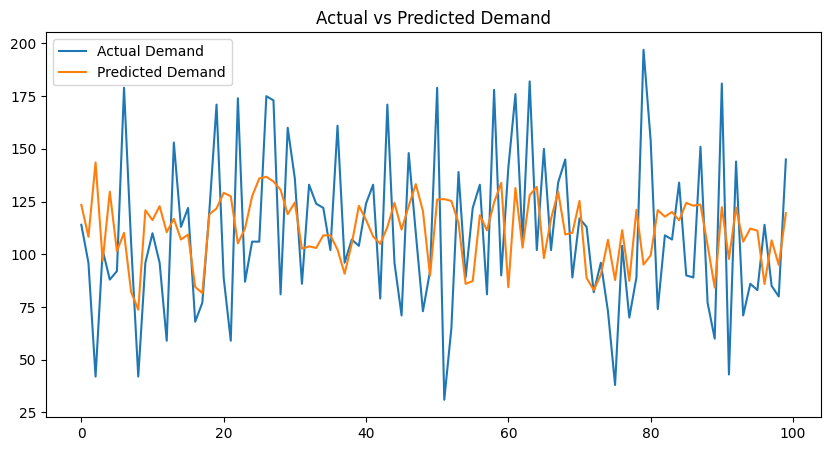

In [26]:
#Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_final[:100], label="Actual Demand")
plt.plot(y_pred_final[:100], label="Predicted Demand")
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()

In [9]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

d = pd.read_csv("demand_forecasting.csv")
d.columns = d.columns.str.strip().str.replace(" ", "_")
print("Rows:", len(d), "| Nulls:", int(d.isnull().sum().sum()))

d = d.drop(columns=["Date"])
d = d.reset_index(drop=True)
d["Time_Step"] = range(len(d))

y2 = d["Demand"]
X2 = d.drop(columns=["Demand"]).copy()

for col in X2.select_dtypes(include="object").columns:
    X2[col] = LabelEncoder().fit_transform(X2[col])

scaler2 = MinMaxScaler()
scaler2.fit(X2)

print("X columns:", list(X2.columns))
print("Number of features:", X2.shape[1])
print("Time_Step min/max:", X2["Time_Step"].min(), X2["Time_Step"].max())
print("y min/max/mean:", y2.min(), y2.max(), y2.mean())

joblib.dump(scaler2, "scaler.pkl")
print("scaler saved")

Rows: 76000 | Nulls: 0
X columns: ['Store_ID', 'Product_ID', 'Category', 'Region', 'Inventory_Level', 'Units_Sold', 'Units_Ordered', 'Price', 'Discount', 'Weather_Condition', 'Promotion', 'Competitor_Pricing', 'Seasonality', 'Epidemic', 'Time_Step']
Number of features: 15
Time_Step min/max: 0 75999
y min/max/mean: 4 430 104.31715789473684
scaler saved


In [10]:
import numpy as np, pandas as pd, joblib
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

m = load_model("lstm_model.h5")
sc = joblib.load("scaler.pkl")

d = pd.read_csv("demand_forecasting.csv")
d.columns = d.columns.str.strip().str.replace(" ", "_")
d = d.drop(columns=["Date"]).reset_index(drop=True)
d["Time_Step"] = range(len(d))
y2 = d["Demand"].values
X2 = d.drop(columns=["Demand"]).copy()
for col in X2.select_dtypes(include="object").columns:
    X2[col] = LabelEncoder().fit_transform(X2[col])

Xs = sc.transform(X2)
print("scaled min/max:", Xs.min(), Xs.max())

for f in (0.1, 0.4, 0.7, 0.9):
    i = int(len(d) * f)
    real = float(m.predict(Xs[i-10:i].reshape(1, 10, 15), verbose=0)[0][0])
    same = float(m.predict(np.tile(Xs[i], (10, 1)).reshape(1, 10, 15), verbose=0)[0][0])
    print("actual:", y2[i], "| pred (real 10 rows):", round(real, 2), "| pred (same row x10):", round(same, 2))

scaled min/max: 0.0 1.0
actual: 92 | pred (real 10 rows): 100.49 | pred (same row x10): 78.58
actual: 93 | pred (real 10 rows): 90.68 | pred (same row x10): 68.72
actual: 75 | pred (real 10 rows): 98.97 | pred (same row x10): 77.75
actual: 164 | pred (real 10 rows): 95.95 | pred (same row x10): 71.87
